In [1]:
import matplotlib.pyplot as plt
import numpy as np
import common
from dataclasses import dataclass
from typing import List
from matplotlib.patches import Arc


In [2]:
def circarrow(self,diameter,centX,centY,startangle,angle,**kwargs):
    startarrow=kwargs.pop("startarrow",False)
    endarrow=kwargs.pop("endarrow",False)

    arc = Arc([centX,centY],diameter,diameter,angle=startangle,
          theta1=np.rad2deg(kwargs.get("head_length",1.5*3*.001)) if startarrow else 0,theta2=angle-(np.rad2deg(kwargs.get("head_length",1.5*3*.001)) if endarrow else 0),linestyle="-",color=kwargs.get("color","black"))
    self.axes().add_patch(arc)

    if startarrow:
        startX=diameter/2*np.cos(np.radians(startangle))
        startY=diameter/2*np.sin(np.radians(startangle))
        startDX=+.000001*diameter/2*np.sin(np.radians(startangle)+kwargs.get("head_length",1.5*3*.001))
        startDY=-.000001*diameter/2*np.cos(np.radians(startangle)+kwargs.get("head_length",1.5*3*.001))
        self.arrow(startX-startDX,startY-startDY,startDX,startDY,**kwargs)

    if endarrow:
        endX=diameter/2*np.cos(np.radians(startangle+angle))
        endY=diameter/2*np.sin(np.radians(startangle+angle))
        endDX=-.000001*diameter/2*np.sin(np.radians(startangle+angle)-kwargs.get("head_length",1.5*3*.001))
        endDY=+.000001*diameter/2*np.cos(np.radians(startangle+angle)-kwargs.get("head_length",1.5*3*.001))
        self.arrow(endX-endDX,endY-endDY,endDX,endDY,**kwargs)

import types
plt.circarrow = types.MethodType(circarrow,plt)

In [3]:
%config InlineBackend.figure_format = 'retina'

In [4]:
@dataclass
class BarPlotData:
    y: List[float]
    name: str

[116508.44444444444, 16847.300771208225, 8645.910290237467, 0.0]
[116508.44444444444, 17246.315789473683, 20739.24050632911, 4277.806788511749]
[127254.36893203884, 20544.20062695925, 126030.76923076922, 21005.128205128203]


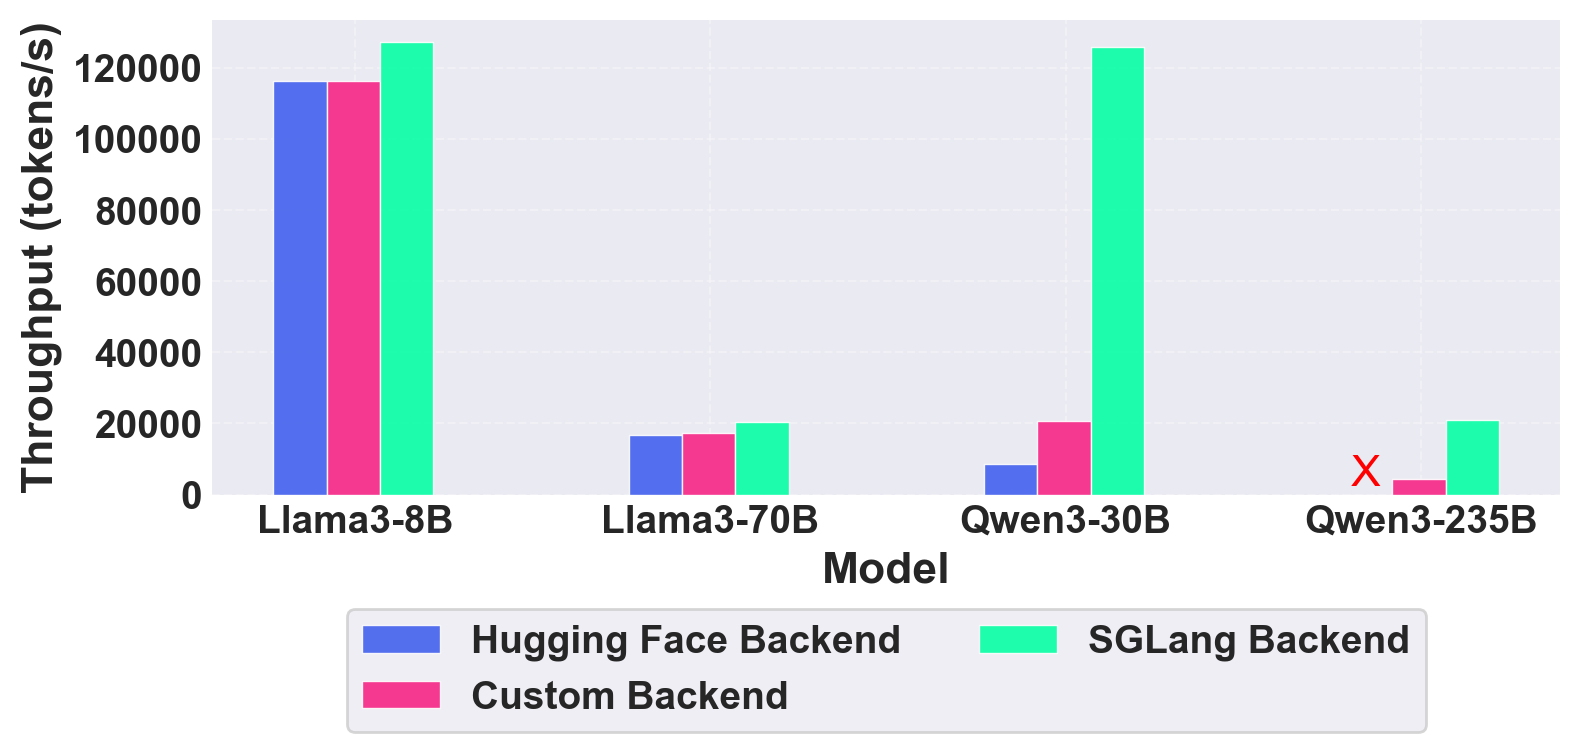

In [6]:
def generate_bar_plot(data_list: List[BarPlotData], x_label: str, y_label: str, title: str, x_ticks: List[str], show_legend: bool = True, show_grid: bool = True, num_legend_cols: int = 2):
    plt.figure(figsize=(8, 4))
    
    # compute the x point of each bar
    num_bars = len(data_list[0].y)
    num_data = len(data_list)
    
    # x = np.arange(num_bars)
    x = np.array([100, 200, 300, 400])
    bar_width = 15

    for idx, data in enumerate(data_list):
        cur_x = x + (idx - num_data / 2) * bar_width + bar_width // 2
        plt.bar(
            x=cur_x, 
            height=data.y, 
            color=common.COLORS[idx], 
            edgecolor='white', 
            linewidth=0.5, 
            alpha=0.9, 
            width=bar_width,
            label=data.name
            )
    
    # add a X in red on the last bar of the first data
    last_bar_x = x[-1] + (0 - num_data / 2) * bar_width + bar_width // 2
    plt.text(last_bar_x, 0, 'X',
        ha='center', va='bottom', fontsize=common.LABEL_FONT_SIZE, color='red')

    plt.xlabel(x_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')
    plt.ylabel(y_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')

    if title:
        plt.title(title, fontsize=common.TITLE_SIZE, fontweight='bold', pad=20)

    if x_ticks:
        plt.xticks(x, x_ticks, fontsize=common.X_TICK_FONT_SIZE, fontweight='bold')
        plt.yticks(fontsize=common.Y_TICK_FONT_SIZE, fontweight='bold')

    if show_legend:
        # put legend below the plot
        plt.legend(frameon=True, prop={'weight': 'bold', 'size': 14}, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)

    if show_grid:
        plt.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()



# Generate sample data
months = ['Llama3-8B', 'Llama3-70B', 'Qwen3-30B', 'Qwen3-235B']
batch_size = np.array([64, 16, 16, 8])
seq_length = 4096

step_time_hf = np.array([2.25, 3.89, 7.58, -1])
step_time_custom = np.array([2.25, 3.80, 3.16, 7.66])
step_time_sglang = np.array([2.06, 3.19, 0.52, 1.56])

throughput_custom = batch_size * seq_length / step_time_custom
throughput_sglang = batch_size * seq_length / step_time_sglang
throughput_hf = batch_size * seq_length / step_time_hf
throughput_hf[-1] = 0

throughput_custom = throughput_custom.tolist()
throughput_sglang = throughput_sglang.tolist()
throughput_hf = throughput_hf.tolist()

print(throughput_hf)
print(throughput_custom)
print(throughput_sglang)

data_list = [
        BarPlotData(y=throughput_hf, name='Hugging Face Backend'),
        BarPlotData(y=throughput_custom, name='Custom Backend'),
        BarPlotData(y=throughput_sglang, name='SGLang Backend'),
]


generate_bar_plot(
        data_list=data_list,
        x_label='Model',
        y_label='Throughput (tokens/s)',
        title=None,
        x_ticks=months,
        show_legend=True,
        show_grid=True,
        num_legend_cols=1
)
plt.savefig('backend-time.pdf', dpi=300)
plt.show()